In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.io.fits as pf
from lsst.daf.persistence import Butler
import lsst.afw.cameraGeom.utils as camGeomUtils
import lsst.afw.display as afwDisplay

In [15]:
REPO_DIR = '/readonly/lsstdata/auxtel/base/auxtel/oods/butler/repo'
butler = Butler(REPO_DIR)
expId=2021011500011
dayObs = '2021-01-15'

In [21]:
visits = butler.queryMetadata('raw', ['expId', 'EXPTIME', 'DATE'],\
                              detector=0)

In [22]:
print(visits)

[(2021011500003, 0.0, '2021-01-15T20:29:38.100'), (2021011500004, 0.0, '2021-01-15T20:41:17.725'), (2021011500005, 0.0, '2021-01-15T20:52:13.298'), (2021011500006, 0.0, '2021-01-15T21:44:32.207'), (2021011500007, 0.0, '2021-01-15T21:45:31.947'), (2021011500008, 0.0, '2021-01-15T21:46:44.679'), (2021011500009, 60.0, '2021-01-15T21:53:26.461'), (2021011500010, 0.5, '2021-01-15T21:58:23.188'), (2021011500011, 3.0, '2021-01-15T22:00:09.646')]


In [36]:
expId=2021011500008
exp = butler.get('raw', detector=0, expId=expId)
median = np.median(exp.getMaskedImage().getArrays()[0])
std = np.std(exp.getMaskedImage().getArrays()[0])
print(median, std)

2241862.0 2199.7034


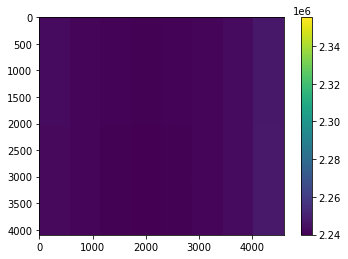

In [34]:
plt.imshow(exp.getMaskedImage().getArrays()[0], interpolation='nearest')
plt.colorbar()

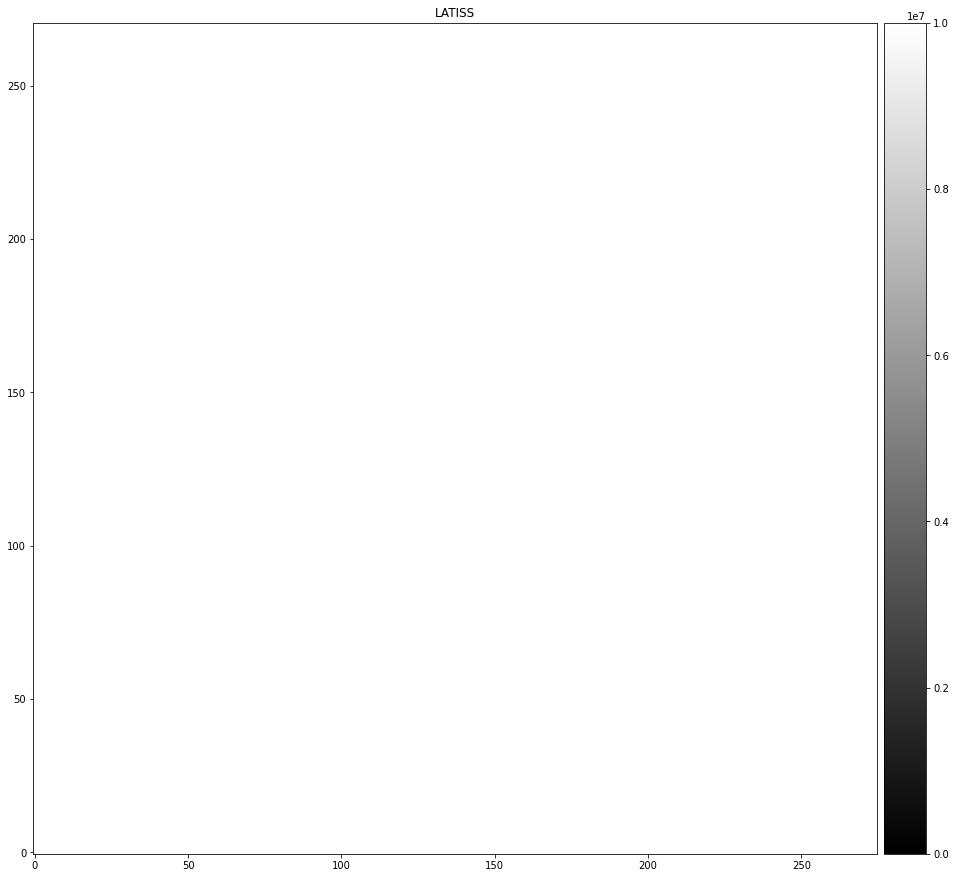

In [35]:
camera = butler.get('camera')
fig = plt.figure(figsize=(16,16))
disp = afwDisplay.Display(1, "matplotlib")
disp.scale('linear',min=0.0,max=1E7)
dataType='raw'
mos = camGeomUtils.showCamera(camera, \
                              camGeomUtils.ButlerImage(butler, dataType, expId=expId, \
                                                        verbose=True,  \
                                                      background = np.nan),\
                              title='',\
                              binSize=16, display=disp, overlay=False)
#fig.savefig(REPO_DIR+'/plots/%s_%d_%s.png'%(testType,visit,dayObs))